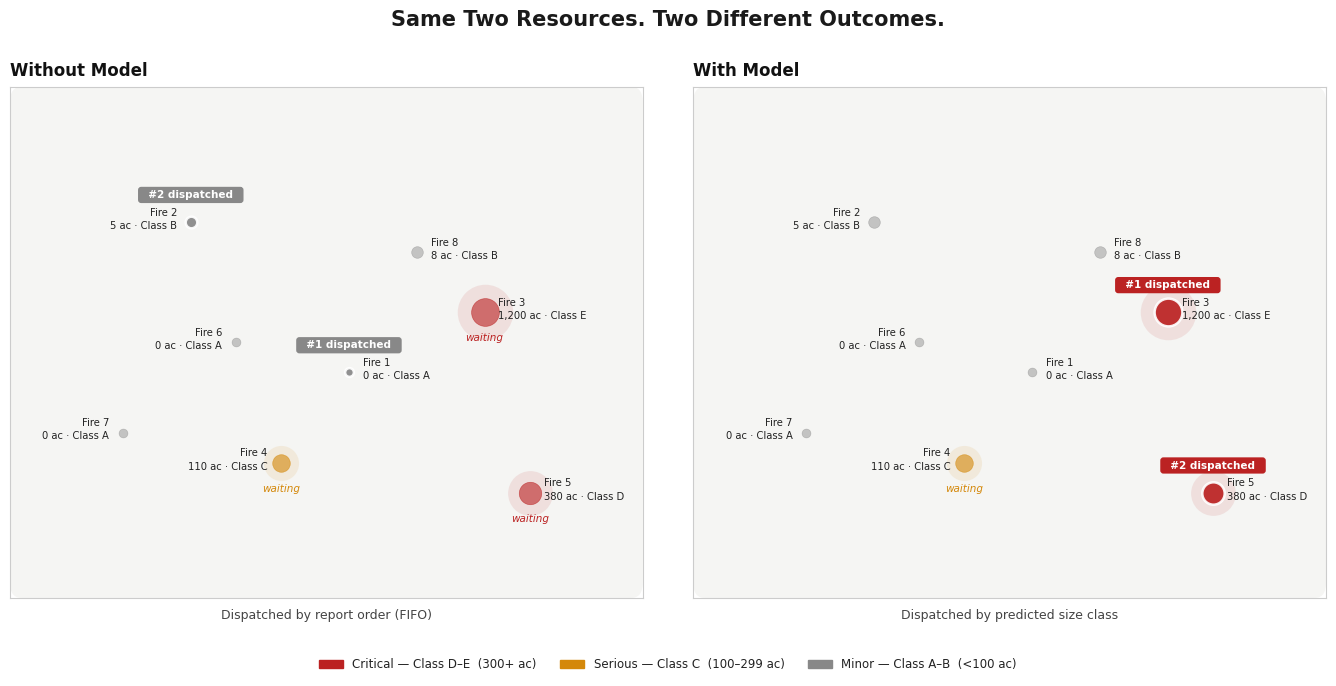

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Fire Incident Data ────────────────────────────────────────────────
# Synthetic but geographically realistic incidents in central California.
# Each tuple: (name, longitude, latitude, size_class, acres, report_order)
# report_order simulates the sequence in which fires were called in —
# this is what FIFO dispatch uses; the model ignores it entirely.
fires = [
    ("Fire 1", -119.8, 37.4, "A", 0.1,  1),
    ("Fire 2", -120.5, 37.9, "B", 5,    2),
    ("Fire 3", -119.2, 37.6, "E", 1200, 3),
    ("Fire 4", -120.1, 37.1, "C", 110,  4),
    ("Fire 5", -119.0, 37.0, "D", 380,  5),
    ("Fire 6", -120.3, 37.5, "A", 0.05, 6),
    ("Fire 7", -120.8, 37.2, "A", 0.2,  7),
    ("Fire 8", -119.5, 37.8, "B", 8,    8),
]

# ── Visual Encoding by Size Class ────────────────────────────────────
# color encodes severity tier; size encodes predicted acreage.
# A and B share gray (minor), C is amber (serious), D and E share red (critical).
class_config = {
    "A": {"color": "#888888", "size": 40},
    "B": {"color": "#888888", "size": 70},
    "C": {"color": "#D4880A", "size": 160},
    "D": {"color": "#BB2222", "size": 260},
    "E": {"color": "#BB2222", "size": 400},
}

# ── Dispatch Decisions ────────────────────────────────────────────────
# FIFO: first two fires reported get the resources regardless of severity.
# Model: the two fires predicted to grow largest get resources first.
fifo_dispatched  = {"Fire 1", "Fire 2"}
model_dispatched = {"Fire 3", "Fire 5"}

# ── Figure Setup ──────────────────────────────────────────────────────
# Two side-by-side panels on a white background — one per dispatch scenario.
fig, axes = plt.subplots(1, 2, figsize=(14, 7), facecolor="white")

# centered supertitle sits above both panels
fig.text(0.5, 0.97, "Same Two Resources. Two Different Outcomes.",
         ha="center", va="top",
         fontsize=15, fontweight="bold", color="#1A1A1A")

# top=0.86 reserves space for the supertitle above the plot area
fig.subplots_adjust(top=0.86, bottom=0.13, left=0.03, right=0.97, wspace=0.08)

# panel metadata: title, x-axis subtitle, and which fires are dispatched
panels = [
    ("Without Model",  "Dispatched by report order (FIFO)",  fifo_dispatched),
    ("With Model",     "Dispatched by predicted size class",  model_dispatched),
]

# ── Draw Each Panel ───────────────────────────────────────────────────
for ax, (title, subtitle, dispatched) in zip(axes, panels):
    ax.set_facecolor("white")

    # longitude/latitude bounds covering central California
    ax.set_xlim(-121.3, -118.5)
    ax.set_ylim(36.65, 38.35)

    # suppress tick marks — this is a schematic map, not a data plot
    ax.set_xticks([])
    ax.set_yticks([])

    # light border to frame the panel
    for spine in ax.spines.values():
        spine.set_color("#CCCCCC")
        spine.set_linewidth(0.8)

    # subtle background rectangle to suggest a map canvas
    ax.add_patch(mpatches.FancyBboxPatch(
        (-121.25, 36.7), 2.7, 1.6,
        boxstyle="round,pad=0.05",
        linewidth=0, facecolor="#F5F5F3", zorder=0
    ))

    for name, lon, lat, cls, acres, order in fires:
        cfg = class_config[cls]
        is_dispatched = name in dispatched
        is_large = cls in ("C", "D", "E")   # fires large enough to warrant a "waiting" label

        # translucent halo around large fires to visually convey potential spread radius
        if is_large:
            ax.scatter(lon, lat, s=cfg["size"] * 4,
                       color=cfg["color"], alpha=0.10, zorder=1, linewidths=0)

        # main fire dot — dispatched fires are fully opaque with a white ring,
        # large waiting fires are semi-transparent, small fires are faded
        alpha = 0.92 if is_dispatched else (0.60 if is_large else 0.45)
        ax.scatter(lon, lat, s=cfg["size"],
                   color=cfg["color"], alpha=alpha,
                   edgecolors="white" if is_dispatched else cfg["color"],
                   linewidths=1.8 if is_dispatched else 0.5,
                   zorder=3)

        # ranked dispatch badge above dot for fires that received a resource
        if is_dispatched:
            rank = sorted(dispatched).index(name) + 1
            ax.annotate(
                f"  #{rank} dispatched  ",
                xy=(lon, lat), xytext=(0, 16),
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=7.5, fontweight="bold", color="white",
                bbox=dict(boxstyle="round,pad=0.3", fc=cfg["color"], ec="none"),
                zorder=6
            )

        # italic "waiting" label below large fires that did not receive a resource
        elif is_large:
            ax.annotate(
                "waiting",
                xy=(lon, lat), xytext=(0, -15),
                textcoords="offset points",
                ha="center", va="top",
                fontsize=7.5, color=cfg["color"],
                fontstyle="italic", zorder=5
            )

        # fire name and size label — offset left or right based on longitude
        # so labels don't overlap the dot or fall outside the panel
        x_off = 10 if lon > -119.9 else -10
        ha = "left" if lon > -119.9 else "right"
        ax.annotate(
            f"{name}\n{acres:,.0f} ac · Class {cls}",
            xy=(lon, lat), xytext=(x_off, 2),
            textcoords="offset points",
            ha=ha, va="center",
            fontsize=7.2, color="#222222",
            linespacing=1.4, zorder=5
        )

    # panel-level title and subtitle
    ax.set_title(title, fontsize=12, fontweight="bold",
                 color="#111111", loc="left", pad=8)
    ax.set_xlabel(subtitle, fontsize=9, color="#444444", labelpad=8)

# ── Shared Legend ─────────────────────────────────────────────────────
# three severity tiers match the color encoding used in both panels
legend_handles = [
    mpatches.Patch(color="#BB2222", label="Critical — Class D–E  (300+ ac)"),
    mpatches.Patch(color="#D4880A", label="Serious — Class C  (100–299 ac)"),
    mpatches.Patch(color="#888888", label="Minor — Class A–B  (<100 ac)"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3,
           fontsize=8.5, frameon=False,
           bbox_to_anchor=(0.5, 0.01),
           labelcolor="#222222")

# ── Save & Display ────────────────────────────────────────────────────
plt.savefig("dispatch_comparison.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()